<div style="padding: 25px; border: 2px solid #2c3e50; border-radius: 12px; background-color: #ffffff; color: #1a1a1a; font-family: 'Segoe UI', Helvetica, Arial, sans-serif;box-sizing: border-box; max-width: 100%; word-wrap: break-word; overflow-wrap: break-word;">

<h1 style="color: #004080; border-bottom: 3px solid #004080; padding-bottom: 10px; font-weight: 800; margin-top: 0;">
    Aquaverse Short Course Part III: Mapping Satellite Imagery
</h1>

<p style="font-size: 1.15em; line-height: 1.7; color: #222222;">
    This notebook illustrates how to apply the pretrained <b>Mixture Density Network (MDN)</b> models within the Aquaverse framework to map spatial distributions of Water Quality (WQ) parameters over entire satellite scenes. You will learn how to load satellite image cubes, preprocess spatial data, execute parallelized MDN model inferences using Dask execution grids, and output high-resolution geographic raster maps of water constituents alongside pixel-by-pixel uncertainty boundaries.
</p>

<h3 style="color: #004080; margin-top: 25px;"><b>Course Objectives</b></h3>
<ul style="line-height: 1.9; color: #1a1a1a; list-style-type: none; padding-left: 0;">
    <li><span style="color: #d35400;">■</span> <b>01. Downloading Example Satellite Data:</b> Download and extract sample satellite imagery to use as the base demonstration dataset.</li>
    <li><span style="color: #d35400;">■</span> <b>02. Visualizing TOA and R<sub>rs</sub> Data:</b> Load, inspect, and plot Top-of-Atmosphere (TOA) reflectance and surface Remote Sensing Reflectance (<span style="font-family: 'Times New Roman', serif; font-weight: bold; font-style: italic; color: #000000; font-size: 1.1em;">R<sub style="font-style: normal; font-size: 0.75em; vertical-align: sub;">rs</sub></span>) data layers.</li>
    <li><span style="color: #d35400;">■</span> <b>03. Generating MDN Predictions:</b> Apply the pretrained MDN models to estimate target water quality parameters across the spatial extent of the imagery.</li>
    <li><span style="color: #d35400;">■</span> <b>04. Visualizing Predictions and Uncertainties:</b> Map the generated spatial predictions alongside their corresponding pixel-by-pixel uncertainty boundaries.</li>
    <li><span style="color: #d35400;">■</span> <b>05. Exporting and Saving Products:</b> Save and export the final prediction and uncertainty arrays into GIS-compatible raster formats for external use.</li>
</ul>

<div style="background-color: #fcf8e3; color: #8a6d3b; padding: 15px; border: 1px solid #faebcc; border-left: 6px solid #8a6d3b; margin: 20px 0; font-weight: 500;box-sizing: border-box; max-width: 100%; word-wrap: break-word; overflow-wrap: break-word;">
    <strong>Requirement:</strong> Assumes that the user has successfully run the previous notebook in this tutorial (<a href="AQV_2_MDN_predictions.ipynb" style="color: #0056b3; text-decoration: underline; font-weight: bold;">AQV_2_MDN_predictions.ipynb</a>), has a working Dask/Xarray environment, and has verified local access to the required internet resources to download the demo dataset.
</div>

<hr style="border: 0; border-top: 2px solid #eee;">

<div style="margin-bottom: 20px;">
    <strong style="color: #004080; font-size: 1.1em;">Freshwater Sensing Group</strong><br>
    <span style="color: #444;">Science Systems and Applications, Inc. / NASA Goddard Space Flight Center</span><br>
    <span style="color: #666;">August 2026</span>
</div>

<h4 style="color: #004080; margin-bottom: 10px;">Technical Contacts</h4>
<table style="width: 100%; border-collapse: collapse; border: 1px solid #ddd;">
    <thead style="background-color: #f2f2f2;">
        <tr>
            <th style="text-align: left; padding: 12px; border: 1px solid #ddd; color: #004080;">Domain</th>
            <th style="text-align: left; padding: 12px; border: 1px solid #ddd; color: #004080;">Section Lead</th>
            <th style="text-align: left; padding: 12px; border: 1px solid #ddd; color: #004080;">Email</th>
        </tr>
    </thead>
    <tbody>
        <tr>
            <td style="padding: 10px; border: 1px solid #ddd; font-weight: 500;">BPs & IOP Products</td>
            <td style="padding: 10px; border: 1px solid #ddd;">Ryan E. O'Shea</td>
            <td style="padding: 10px; border: 1px solid #ddd;"><a href="mailto:ryan.oshea@ssaihq.com" style="color: #0056b3; font-weight: bold;">ryan.oshea@ssaihq.com</a></td>
        </tr>
        <tr style="background-color: #fafafa;">
            <td style="padding: 10px; border: 1px solid #ddd; font-weight: 500;">Uncertainties</td>
            <td style="padding: 10px; border: 1px solid #ddd;">Arun Saranathan</td>
            <td style="padding: 10px; border: 1px solid #ddd;"><a href="mailto:arun.saranathan@ssaihq.com" style="color: #0056b3; font-weight: bold;">arun.saranathan@ssaihq.com</a></td>
        </tr>
        <tr>
            <td style="padding: 10px; border: 1px solid #ddd; font-weight: 500;">Atmospheric Correction</td>
            <td style="padding: 10px; border: 1px solid #ddd;">Akash Ashapure</td>
            <td style="padding: 10px; border: 1px solid #ddd;"><a href="mailto:akash.ashapure@ssaihq.com" style="color: #0056b3; font-weight: bold;">akash.ashapure@ssaihq.com</a></td>
        </tr>
        <tr style="background-color: #fafafa;">
            <td style="padding: 10px; border: 1px solid #ddd; font-weight: 500;">Stream Website</td>
            <td style="padding: 10px; border: 1px solid #ddd;">William Wainwright</td>
            <td style="padding: 10px; border: 1px solid #ddd;"><a href="mailto:william.wainwright@ssaihq.com" style="color: #0056b3; font-weight: bold;">william.wainwright@ssaihq.com</a></td>
        </tr>
    </tbody>
</table>

</div>

In [16]:
# -*- coding: utf-8 -*-# 

# Import the base python packages needed for this notebook
import numpy                                                          as np
import xarray                                                         as xr
import scipy
import re
import os
import subprocess
from   pathlib                    import Path
from   urllib.request             import urlretrieve
import zipfile
%matplotlib inline
import matplotlib                                                     as mpl
import matplotlib.pyplot                                              as plt
import matplotlib.patches                                             as patches
from   matplotlib                 import ticker
from   matplotlib.colors          import LogNorm
import sys
# Get the parent directory path
parent_dir = os.path.abspath(os.path.join(os.getcwd(), '..'))

# Insert it at the beginning of the path list so Python checks it first
if parent_dir not in sys.path:
    sys.path.insert(0, parent_dir)
    
# Supressing tensorflow based warnings
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
import warnings
warnings.filterwarnings('ignore', category=DeprecationWarning)
warnings.filterwarnings('ignore', category=UserWarning)
import tensorflow as tf
tf.get_logger().setLevel('ERROR')
tf.autograph.set_verbosity(0)
import logging
logging.getLogger('tensorflow').setLevel(logging.ERROR)
logging.getLogger('tensorflow_probability').setLevel(logging.ERROR)

# Import some specific functions and packages from MDN implementation
from   MDN                        import download_example_imagery, print_available_imagery, export_dataset
from   MDN                        import display_sat_rgb, get_sensor_bands, extract_satellite_data, overlay_rgb_mdn_preds_limits
from   MDN                        import extract_satellite_data, get_sensor_bands, translate_wavelengths_to_landsat_bands, map_cube_mdn

In [17]:
# Set display parameters via MATPLOTLIB for this notebook
plt.rcParams.update({"text.usetex": False,})
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['DejaVu Sans']

plt.rcParams['mathtext.default'] = 'regular'
SMALL_SIZE = 12
MEDIUM_SIZE = 14
BIGGER_SIZE = 16
mrkSize = 15
ASPECT = "auto"
cmap = "jet"

mpl.rcParams['xtick.labelsize'] = SMALL_SIZE
mpl.rcParams['ytick.labelsize'] = SMALL_SIZE

plt.rc('font', size=SMALL_SIZE)  # controls default text sizes
plt.rc('axes', titlesize=SMALL_SIZE)  # fontsize of the axes title
plt.rc('axes', labelsize=MEDIUM_SIZE)  # fontsize of the x and y labels
plt.rc('xtick', labelsize=SMALL_SIZE)  # fontsize of the tick labels
plt.rc('ytick', labelsize=SMALL_SIZE)  # fontsize of the tick labels
plt.rc('legend', fontsize=MEDIUM_SIZE)  # legend fontsize
plt.rc('figure', titlesize=BIGGER_SIZE)

<div style="padding: 25px; border: 2px solid #2c3e50; border-radius: 12px; background-color: #ffffff; color: #1a1a1a; font-family: 'Segoe UI', Helvetica, Arial, sans-serif; line-height: 1.6; width: auto; max-width: 100%; box-sizing: border-box; overflow: hidden;">

<h2 style="color: #c0392b; border-bottom: 2px solid #c0392b; padding-bottom: 8px; font-weight: 700; margin-top: 0; margin-bottom: 20px; font-size: 1.5em; word-wrap: break-word;">
    Section 1: Downloading Satellite Data to Test MDN Performance
</h2>

<p style="margin-bottom: 15px; word-wrap: break-word;">To properly test and evaluate our <strong>MDN (Mixture Density Network)</strong> package, we need to work with actual, real-world satellite imagery. However, not just any satellite data will do. Please ensure your imagery meets the following specifications:</p>

<ul style="padding-left: 20px; margin-bottom: 20px; list-style-type: disc;">
    <li style="margin-bottom: 10px; word-wrap: break-word;">
        <strong>Level-2 Processing (Atmospherically Corrected):</strong> The satellite data must be Level-2, meaning it has undergone Atmospheric Correction (AC). This correction can be performed using a variety of standard techniques, such as <code>ACOLITE</code>, <code>L2GEN</code>, <code>POLYMER</code>, or our own native <code>AQUAVERSE-AC</code> processor.
    </li>
    <li style="margin-bottom: 10px; word-wrap: break-word;">
        <strong>Land Masking:</strong> The datasets should be land-masked to isolate the aquatic pixels and optimize processing efficiency.
    </li>
</ul>

<div style="background-color: #f8f9fa; border-left: 4px solid #c0392b; padding: 15px; margin: 20px 0; border-radius: 0 4px 4px 0; box-sizing: border-box;">
    <p style="margin: 0; font-weight: 500; word-wrap: break-word;">
        💡 <strong>Need data to get started?</strong><br>
        To help you jump right into this tutorial, we have provided curated sample satellite datasets. You can automatically fetch and download this data directly within your notebook using our built-in <code>download_example_imagery()</code> function.
    </p>
</div>

<div style="background-color: #fdf2f2; color: #9b1c1c; padding: 15px; border: 1px solid #f8b4b4; border-left: 6px solid #e11d48; margin: 20px 0; box-sizing: border-box; border-radius: 4px;">
    <strong style="font-size: 1.1em;">⚠️ Team Internal Note: Things to implement in this section</strong>
    <ol style="margin-top: 5px; margin-bottom: 0; padding-left: 20px; line-height: 1.7;">
        <li><b>Explain L1 vs. L2 differences:</b> Clearly differentiate between Level-1 (TOA reflectance, <span style="font-family: 'Times New Roman', serif; font-weight: bold; font-style: italic;">&rho;<sub style="font-style: normal; font-size: 0.75em; vertical-align: sub;">t</sub></span>) and Level-2 (Surface reflectance, <span style="font-family: 'Times New Roman', serif; font-weight: bold; font-style: italic;">R<sub style="font-style: normal; font-size: 0.75em; vertical-align: sub;">rs</sub></span>). Explicitly point out to the user that the unmasked visual RGB composites use L1 data, whereas the actual MDN processor strictly requires the atmospherically corrected and land-masked L2 data.</li>
    </ol>
</div>

<hr style="border: 0; border-top: 1px solid #eeeeee; margin: 20px 0;">

<div style="font-size: 0.9em; color: #666666; font-style: italic; text-align: right;">
    Aquaverse Short Course • Module 3.1
</div>

</div>

In [18]:
print_available_imagery()

SENSOR     | DATE         | LOCATION            
--------------------------------------------------
HICO       | 09-08-2014   | Lake Erie           
OLCI       | 03-16-2019   | San Francisco Bay   
OLCI       | 06-08-2018   | Utah Lake           
OLCI       | 08-29-2016   | Lake Erie           
OLI        | 03-16-2019   | San Francisco Bay   
PACE       | 05-31-2024   | Lake Erie           
PACE       | 06-12-2024   | Lake Erie           
PACE       | 09-16-2024   | Lake Erie           


<div style="padding: 20px; border: 2px solid #2c3e50; border-radius: 12px; background-color: #ffffff; color: #1a1a1a; font-family: 'Segoe UI', Helvetica, Arial, sans-serif; line-height: 1.6; width: auto; max-width: 100%; box-sizing: border-box; overflow: hidden;">

<p style="margin-bottom: 15px; word-wrap: break-word;">For this first demo, you are encouraged to download the image of the <strong>San Francisco Bay</strong> acquired by the <strong>OLCI</strong> sensor on <strong>03-16-2019</strong>. We will fetch this data using the <code>download_example_imagery</code> function from the <code>MDN</code> package.</p>

<p style="margin-bottom: 15px; word-wrap: break-word;">When running this workflow outside of the demo, you are highly encouraged to experiment with the other available sensor, date, and location combinations available as shown by the <code>print_available_imagery()</code> utility above.</p>

<div style="background-color: #e8f4fd; color: #2b5797; padding: 15px; border: 1px solid #d2e3f7; border-left: 6px solid #2b5797; margin: 20px 0; box-sizing: border-box;">
    <strong style="font-size: 1.1em;">Operational Note:</strong> When configuring your target parameters, ensure the products you choose are a valid subset of one of the available models as shown in <a href="AQV_2_MDN_predictions.ipynb" style="color: #0056b3; text-decoration: underline; font-weight: bold;">AQV_2_MDN_predictions.ipynb</a>.
</div>

</div>

In [19]:
# Provide data details for the example imagery to be downloaded
sensor= "OLCI"
products = "chl,tss"
date= "03-16-2019"
location = "San Francisco Bay"
tile_path = download_example_imagery(sensor= sensor, date= date, location= location)

# Let us load the NetCDF lazily and display the global attributes
ds = xr.open_dataset(tile_path)

# A dictionary mapping clear, user-friendly labels to your specific NetCDF keys
# 1. Gather the core metadata dictionary
useful_metadata = {
    "Core Information": {
        "Processor/Software": ds.attrs.get("generated_by"),
        "Processing Date": ds.attrs.get("generated_on"),
        "Sensor Baseline": ds.attrs.get("sensor"),
        "Acquisition Time": ds.attrs.get("isodate"),
        "File Type": ds.attrs.get("acolite_file_type"),
    },
    "Spatial Dimensions & Bounds": {
        "Image Dimensions (Px)": ds.attrs.get("data_dimensions"),
        "Spatial Bounding Box": ds.attrs.get("limit"),
    },
    "Atmospheric & Environmental Context": {
        "Solar Zenith Angle (SZA)": round(ds.attrs.get("sza", 0), 2),
        "View Zenith Angle (VZA)": round(ds.attrs.get("vza", 0), 2),
        "Ozone Column (uoz)": ds.attrs.get("uoz"),
        "Water Vapor (uwv)": ds.attrs.get("uwv"),
        "Ancillary Data Source": ds.attrs.get("ancillary_type")
    },
    "Masking Settings (Crucial for MDN)": {
        "Land/Water Masking Wave": f"{ds.attrs.get('l2w_mask_wave')} nm",
        "Water Mask Threshold": ds.attrs.get("l2w_mask_threshold"),
        "High TOA Cloud Masking": str(ds.attrs.get("l2w_mask_high_toa"))
    }
}

# 2. Extract variable bases and drop repeats/wavelengths
coordinate_vars = {'lat', 'lon', 'transverse_mercator', 'x', 'y'}
unique_parameter_keys = set()

for var in ds.data_vars:
    if var in coordinate_vars:
        continue
    # Strip trailing underscores followed by numbers (e.g., rhow_443 -> rhow)
    base_key = re.sub(r'_\d+$', '', var)
    unique_parameter_keys.add(base_key)

# Convert back to a sorted list
sorted_keys = sorted(list(unique_parameter_keys))

# 3. Print the full summary
print("=" * 60)
print("             SATELLITE NETCDF MULTI-PREVIEW             ")
print("=" * 60)

# Print attributes
for section, items in useful_metadata.items():
    print(f"\n📁 {section.upper()}")
    print("-" * len(section))
    for key, value in items.items():
        if isinstance(value, list) or str(type(value)).endswith("ndarray'>"):
            value = [round(x, 4) for x in value] if isinstance(value[0], (int, float)) else value
        print(f"  🔹 {key:<26} : {value}")

# Print unique parameter fields
print("\n📊 AVAILABLE PARAMETER KEYS (Wavelength Repeats Dropped)")
print("-------------------------------------------------------")
print(f"  👉 {', '.join(sorted_keys)}")
print("\n" + "=" * 60)

             SATELLITE NETCDF MULTI-PREVIEW             

📁 CORE INFORMATION
----------------
  🔹 Processor/Software         : ACOLITE
  🔹 Processing Date            : 2024-08-20 13:18:53 EDT
  🔹 Sensor Baseline            : S3B_OLCI
  🔹 Acquisition Time           : 2019-03-16T18:42:38.875566+00:00
  🔹 File Type                  : L2R

📁 SPATIAL DIMENSIONS & BOUNDS
---------------------------
  🔹 Image Dimensions (Px)      : [589 768]
  🔹 Spatial Bounding Box       : [np.float64(37.1073), np.float64(-123.276), np.float64(38.3802), np.float64(-121.5071)]

📁 ATMOSPHERIC & ENVIRONMENTAL CONTEXT
-----------------------------------
  🔹 Solar Zenith Angle (SZA)   : 45.1
  🔹 View Zenith Angle (VZA)    : 11.58
  🔹 Ozone Column (uoz)         : 0.3127064710481136
  🔹 Water Vapor (uwv)          : 1.0152477237338193
  🔹 Ancillary Data Source      : GMAO_MERRA2_MET

📁 MASKING SETTINGS (CRUCIAL FOR MDN)
----------------------------------
  🔹 Land/Water Masking Wave    : 1020 nm
  🔹 Water Mask Thresh

<div style="padding: 20px; border: 2px solid #2c3e50; border-radius: 12px; background-color: #ffffff; color: #1a1a1a; font-family: 'Segoe UI', Helvetica, Arial, sans-serif; line-height: 1.6; width: auto; max-width: 100%; box-sizing: border-box; overflow: hidden;">

<p style="margin-bottom: 15px; word-wrap: break-word;">By executing the <code>download_example_imagery</code> function with a valid combination of location, sensor, and date, the requested file will be automatically downloaded and saved locally into the <code>./data/example_imagery</code> directory structure.</p>

<hr style="border: 0; border-top: 1px solid #e0e0e0; margin: 20px 0;" />

<h3 style="margin-top: 0; margin-bottom: 10px; color: #2c3e50; font-size: 1.15em;">Understanding Satellite Data Types</h3>

<p style="margin-bottom: 12px; word-wrap: break-word;">Satellite sensors capture light reflecting off the Earth, but the raw signal contains a lot of "atmospheric noise" (like dust, water vapor, and air molecules). Depending on how heavily the data has been cleaned up using an <strong>Atmospheric Correction (AC) processor</strong>, the imagery generally falls into one of three distinct processing levels:</p>

<ul style="margin-bottom: 15px; padding-left: 20px; word-wrap: break-word;">
    <li style="margin-bottom: 6px;"><strong>Top of Atmosphere Radiance (ρ<sub>t</sub>):</strong> Raw, uncorrected data. This measures all the light reaching the satellite's lens, meaning it is heavily distorted by the atmosphere and includes sunlight bouncing off clouds or air particles.</li>
    <li style="margin-bottom: 6px;"><strong>Water Leaving Reflectance (ρ<sub>w</sub>):</strong> Partially corrected data. The atmospheric haze has been calculated and mathematically stripped away, leaving behind only the light signal that actually managed to escape the water's surface.</li>
    <li style="margin-bottom: 6px;"><strong>Remote Sensing Reflectance (R<sub>rs</sub>):</strong> Fully corrected and normalized data. This measures the water-leaving radiance divided by the total light shining down on the surface. It acts as an absolute physical property of the water body, independent of the time of day or weather conditions during the satellite flyover.</li>
</ul>

<p style="margin-bottom: 15px; word-wrap: break-word;">Because these files look structurally identical on the outside, you always need to verify which version you are working with by inspecting the file's inner metadata attributes.</p>

<hr style="border: 0; border-top: 1px solid #e0e0e0; margin: 20px 0;" />

<h3 style="margin-top: 0; margin-bottom: 10px; color: #2c3e50; font-size: 1.15em;">Properties of the Downloaded Cube</h3>

<p style="margin-bottom: 15px; word-wrap: break-word;">Once loaded, the dataset acts as a multi-dimensional array (or data cube). It organizes the physical imagery across <strong>spatial dimensions</strong> (the <code>y</code> and <code>x</code> grid coordinates representing latitude and longitude) paired with <strong>spectral bands</strong> (the discrete wavelengths of light captured by that specific satellite's sensor).</p>

<div style="background-color: #fffaf0; color: #b76e00; padding: 15px; border: 1px solid #ffe8cc; border-left: 6px solid #e67e22; margin: 20px 0; box-sizing: border-box;">
    <strong style="font-size: 1.1em;">🚨 Critical Requirement:</strong> To ensure accurate biophysical predictions, the MDN neural networks are strictly trained to read surface signatures. Therefore, the satellite cube <strong>must be in Remote Sensing Reflectance (R<sub>rs</sub>) format</strong> before you attempt to process it with the MDN pipeline.
</div>

</div>

<div style="padding: 25px; border: 2px solid #2c3e50; border-radius: 12px; background-color: #ffffff; color: #1a1a1a; font-family: 'Segoe UI', Helvetica, Arial, sans-serif; line-height: 1.6; width: auto; max-width: 100%; box-sizing: border-box; overflow: hidden;">

<h2 style="color: #c0392b; border-bottom: 2px solid #c0392b; padding-bottom: 8px; font-weight: 700; margin-top: 0; margin-bottom: 20px; font-size: 1.5em; word-wrap: break-word;">
    Section 2: Visualizing Satellite Data
</h2>

<p style="margin-bottom: 15px; word-wrap: break-word;">Before feeding multi-spectral imagery into our machine learning models, it is essential to inspect the data quality visually. In this section, we compare raw top-of-atmosphere observations against fully processed surface reflectance products to verify masking integrity and atmospheric removal.</p>

<ul style="padding-left: 20px; margin-bottom: 20px; list-style-type: disc;">
    <li style="margin-bottom: 10px; word-wrap: break-word;">
        <strong>1. Top of Atmosphere (TOA) Visual Overview:</strong> We first construct a True-Color (RGB) composite using raw or top-of-atmosphere radiance/reflectance (<span style="font-family: 'Times New Roman', serif; font-weight: bold; font-style: italic;">&rho;<sub style="font-style: normal; font-size: 0.75em; vertical-align: sub;">t</sub></span>). This step provides a holistic, unmasked view of the entire scene—allowing you to inspect cloud coverage, land boundaries, haze, and general scene orientation exactly as seen by the satellite sensor.
    </li>
    <li style="margin-bottom: 10px; word-wrap: break-word;">
        <strong>2. Single-Band Remote Sensing Reflectance (<span style="font-family: 'Times New Roman', serif; font-weight: bold; font-style: italic;">R<sub style="font-style: normal; font-size: 0.75em; vertical-align: sub;">rs</sub></span>) Verification:</strong> Next, we isolate a single spectral band from the Level-2 Remote Sensing Reflectance dataset (typically a green/red band, such as ~560 nm or ~665 nm). Visualizing this processed product confirms that atmospheric haze, glint, land pixels, and cloud contamination have been successfully masked out, leaving clean water signatures for MDN inference.
    </li>
</ul>

<div style="background-color: #f8f9fa; border-left: 4px solid #c0392b; padding: 15px; margin: 20px 0; border-radius: 0 4px 4px 0; box-sizing: border-box;">
    <p style="margin: 0; font-weight: 500; word-wrap: break-word;">
        💡 <strong>Quality Check Tip:</strong><br>
        Always check that the land-mask thresholding has not aggressively clipped near-shore pixels or estuarine channels. The MDN architecture relies on accurate aquatic signatures, so verifying that inland bays and tributaries remain intact is crucial before initiating inference routines.
    </p>
</div>

<hr style="border: 0; border-top: 1px solid #eeeeee; margin: 20px 0;">

<div style="font-size: 0.9em; color: #666666; font-style: italic; text-align: right;">
    Aquaverse Short Course • Module 3.2
</div>

</div>

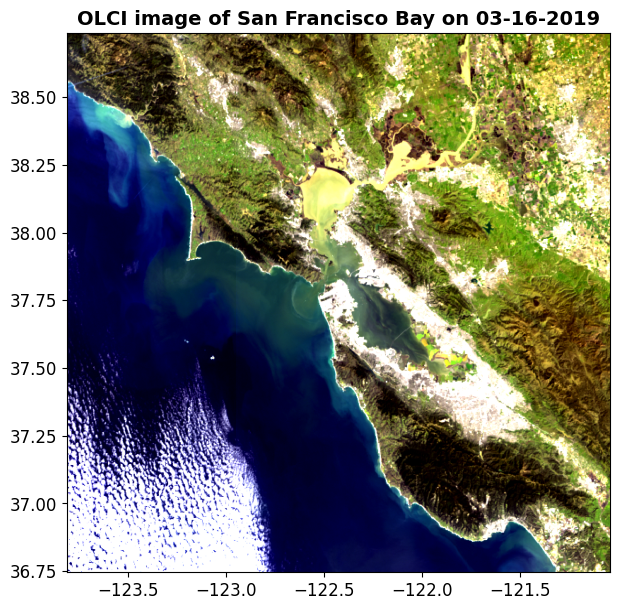

In [20]:
# now display the RGB of the downloaded tile -- this will use the rhos data from the NetCDF file to create a true color image
img_rgb = display_sat_rgb(tile_path, sensor, figsize=(7,7), title=f"{sensor} image of {location} on {date}", ipython_mode=True)

NetCDF file source detected. Delegating to extract_netcdf_satellite_rrs for sensor OLCI: sat_cube.nc
Flat group schema detected. Accessing root level.
Extracted/Assigned Dataset CRS: EPSG:4326
Auto-detected variable type: RRS
Selected variables: ['Rrs_412', 'Rrs_443', 'Rrs_490', 'Rrs_510', 'Rrs_560', 'Rrs_620', 'Rrs_665', 'Rrs_674', 'Rrs_681', 'Rrs_709', 'Rrs_754', 'Rrs_779']
Output spectral shape: (12, 589, 768) (band, y, x)
Latitude/Longitude shape: (589, 768)


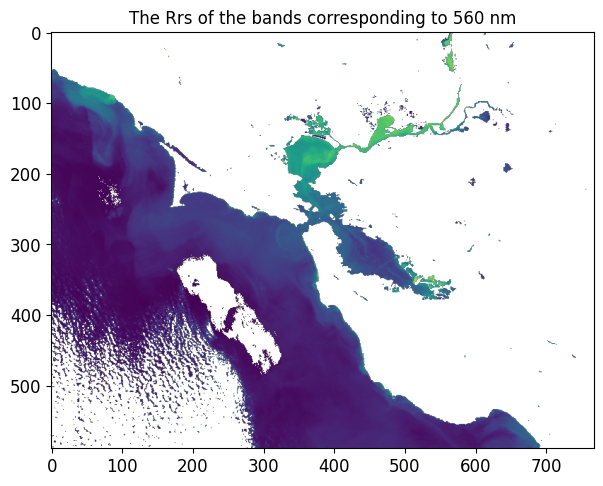

In [21]:
%matplotlib inline

# Let us now extract the Rrs data
bands = get_sensor_bands(sensor)
da= extract_satellite_data(tile_path, sensor=sensor, bands=bands, wavelength_unit="nm", verbose=True, flag_toa=False, chunk_size=400)

# Display the results - for the first band
fig1, ax1 = plt.subplots(figsize=(7,7))
fig1.patch.set_visible(True)

bnd= 4
img1 = ax1.imshow(da.isel(band=bnd), cmap="viridis")
ax1.set_title(f'The Rrs of the bands corresponding to {bands[bnd]} nm');

<div style="padding: 25px; border: 2px solid #2c3e50; border-radius: 12px; background-color: #ffffff; color: #1a1a1a; font-family: 'Segoe UI', Helvetica, Arial, sans-serif; line-height: 1.6; width: auto; max-width: 100%; box-sizing: border-box; overflow: hidden;">

<h2 style="color: #c0392b; border-bottom: 2px solid #c0392b; padding-bottom: 8px; font-weight: 700; margin-top: 0; margin-bottom: 20px; font-size: 1.5em; word-wrap: break-word;">
    Section 4: Generating MDN Predictions
</h2>

<p style="margin-bottom: 15px; word-wrap: break-word;">With our Level-2 Remote Sensing Reflectance (<span style="font-family: 'Times New Roman', serif; font-weight: bold; font-style: italic;">R<sub style="font-style: normal; font-size: 0.75em; vertical-align: sub;">rs</sub></span>) data verified and preprocessed, we are now ready to perform model inference. In this section, we will leverage the built-in prediction utilities of the <strong>MDN package</strong> to generate water quality parameters across the full spatial scene using our pre-trained networks.</p>

<ul style="padding-left: 20px; margin-bottom: 20px; list-style-type: disc;">
    <li style="margin-bottom: 10px; word-wrap: break-word;">
        <strong>1. Loading Pre-trained Models:</strong> We initialize the pipeline using pre-trained Mixture Density Network weights tailored specifically to your target sensor (e.g., Sentinel-2 MSI, Sentinel-3 OLCI) and target aquatic parameters (such as Chlorophyll-a or Total Suspended Solids).
    </li>
    <li style="margin-bottom: 10px; word-wrap: break-word;">
        <strong>2. Executing Spatial Inference:</strong> Using existing MDN mapping functions, the model processes the multi-spectral cube pixel-by-pixel (or chunk-by-chunk). Rather than outputting single point estimates, the network computes the full Gaussian mixture parameters—allowing us to extract central estimates alongside lower (&mu; &minus; &sigma;) and upper (&mu; + &sigma;) uncertainty bounds for every pixel.
    </li>
</ul>

<div style="background-color: #f8f9fa; border-left: 4px solid #c0392b; padding: 15px; margin: 20px 0; border-radius: 0 4px 4px 0; box-sizing: border-box;">
    <p style="margin: 0; font-weight: 500; word-wrap: break-word;">
        💡 <strong>Computational Efficiency:</strong><br>
        For large satellite scenes or high-resolution imagery, ensure you utilize chunked mapping functions (e.g., integrating with <code>Dask</code> or Slurm parallel workers) to prevent memory bottlenecks during array reshaping and mixture density calculations.
    </p>
</div>

<hr style="border: 0; border-top: 1px solid #eeeeee; margin: 20px 0;">

<div style="font-size: 0.9em; color: #666666; font-style: italic; text-align: right;">
    Aquaverse Short Course • Module 3.4
</div>

</div>

<div style="padding: 25px; border: 2px solid #2c3e50; border-radius: 12px; background-color: #ffffff; color: #1a1a1a; font-family: 'Segoe UI', Helvetica, Arial, sans-serif; line-height: 1.6; width: auto; max-width: 100%; box-sizing: border-box; overflow: hidden;">

<h3 style="margin-top: 0; margin-bottom: 10px; color: #2c3e50; font-size: 1.25em;">Understanding <code>map_cube_mdn</code></h3>

<p style="margin-bottom: 15px; word-wrap: break-word;">The primary function for applying Mixture Density Networks across multi-spectral satellite imagery is <code>map_cube_mdn()</code>. This routine processes an entire <code>xarray.DataArray</code> image cube in parallel using <strong>Dask block execution</strong>, making it highly efficient for large spatial scenes.</p>

<hr style="border: 0; border-top: 1px solid #e0e0e0; margin: 20px 0;" />

<h4 style="margin-top: 0; margin-bottom: 10px; color: #2c3e50; font-size: 1.1em;">Key Arguments & Configuration</h4>

<ul style="margin-bottom: 15px; padding-left: 20px; word-wrap: break-word;">
    <li style="margin-bottom: 8px;"><strong>Data & Sensor Setup (<code>img_data</code>, <code>sensor</code>):</strong> Pass your input <code>DataArray</code> containing spatial dimensions (<code>y</code>, <code>x</code>) along with spectral bands. Specify the satellite sensor string (e.g., <code>'MSI'</code>, <code>'OLCI'</code>, <code>'OLI'</code>) so the pipeline automatically loads the correct band configuration and pre-trained weights.</li>
    <li style="margin-bottom: 8px;"><strong>Target Products (<code>products</code>):</strong> Define a comma-separated list of water quality parameters to retrieve simultaneously (e.g., <code>'chl'</code> for Chlorophyll-a, <code>'tss'</code> for Total Suspended Solids, or <code>'chl,tss'</code>).</li>
    <li style="margin-bottom: 8px;"><strong>Uncertainty Quantification (<code>return_uncert</code>, <code>uncert_mode</code>):</strong> When set to <code>True</code> with <code>uncert_mode='limits'</code>, the function returns upper (&mu; + &sigma;) and lower (&mu; &minus; &sigma;) confidence bounds alongside the central estimates for every pixel.</li>
    <li style="margin-bottom: 8px;"><strong>Optional Land Masking (<code>land_mask</code>, <code>landmask_threshold</code>):</strong> Toggle internal near-infrared/shortwave-infrared thresholding to isolate aquatic pixels before running neural network inference.</li>
    <li style="margin-bottom: 8px;"><strong>Progress Monitoring (<code>progress_vis</code>):</strong> Set to <code>True</code> to display a real-time Dask progress bar while parallelized block computation takes place.</li>
</ul>

<div style="background-color: #fffaf0; color: #b76e00; padding: 15px; border: 1px solid #ffe8cc; border-left: 6px solid #e67e22; margin: 20px 0; box-sizing: border-box; border-radius: 4px;">
    <strong style="font-size: 1.05em;">⚡ Dask Chunking Tip:</strong> Ensure your input <code>img_data</code> array is chunked spatially (e.g., <code>img_data.chunk({'y': 500, 'x': 500})</code>) prior to calling <code>map_cube_mdn()</code>. This allows Dask to efficiently distribute workload chunks across all available CPU cores without blowing up system memory.
</div>

</div>

In [22]:
# Generate MDN predictions for this dataset
map_preds, op_slices = map_cube_mdn(da, sensor=sensor, products="chl,tss", return_uncert=True, uncert_mode="limits", scaler_mode="invert", progress_vis=True)
map_preds

Computing MDN predictions across chunks...
[                                        ] | 0% Completed | 68.21 us

[##################################      ] | 86% Completed | 106.64 ms

[##################################      ] | 86% Completed | 211.97 ms

[##################################      ] | 86% Completed | 317.83 ms

[##################################      ] | 86% Completed | 3.13 s ms

...

[######################################  ] | 95% Completed | 12.61 s

[######################################  ] | 95% Completed | 12.71 s

[######################################  ] | 95% Completed | 12.82 s

[########################################] | 100% Completed | 26.27 s


<xarray.Dataset> Size: 14MB
Dimensions:           (model: 1, output: 2, y: 589, x: 768)
Coordinates:
  * model             (model) int64 8B 0
  * output            (output) int64 16B 0 1
  * y                 (y) int64 5kB 0 1 2 3 4 5 6 ... 583 584 585 586 587 588
  * x                 (x) int64 6kB 0 1 2 3 4 5 6 ... 762 763 764 765 766 767
    latitude          (y, x) float32 2MB 38.74 38.74 38.74 ... 36.75 36.75 36.75
    longitude         (y, x) float32 2MB -123.3 -123.3 -123.3 ... -121.6 -121.6
    spatial_ref       int64 8B 0
Data variables:
    predictions       (model, y, x, output) float32 4MB -999.0 -999.0 ... -999.0
    uncertainty_low   (model, y, x, output) float32 4MB -999.0 -999.0 ... -999.0
    uncertainty_high  (model, y, x, output) float32 4MB -999.0 -999.0 ... -999.0
Attributes:
    title:                MDN Satellite Product Predictions
    sensor:               OLCI
    target_products:      chl,tss
    operation_mode:       select
    land_mask_applied:    False
    land_mask_threshold:  0.0
    scaler_mode:          invert
    no_data_value:        -999
    extent:               [-123.81033325195312, -121.03952026367188, 36.74599...
    history:              Created on 2026-09-07 13:24:12 using map_cube_mdn

<div style="padding: 25px; border: 2px solid #2c3e50; border-radius: 12px; background-color: #ffffff; color: #1a1a1a; font-family: 'Segoe UI', Helvetica, Arial, sans-serif; line-height: 1.6; width: auto; max-width: 100%; box-sizing: border-box; overflow: hidden;">

<h2 style="color: #c0392b; border-bottom: 2px solid #c0392b; padding-bottom: 8px; font-weight: 700; margin-top: 0; margin-bottom: 20px; font-size: 1.5em; word-wrap: break-word;">
    Section 4: Visualizing MDN Predictions & Uncertainty
</h2>

<p style="margin-bottom: 15px; word-wrap: break-word;">Once <code>map_cube_mdn()</code> finishes processing the satellite scene, we visualize the retrieved water quality parameters alongside their pixel-wise confidence bounds. Mixture Density Networks model full probability distributions rather than single point estimates, allowing us to inspect both expected parameter concentrations and prediction uncertainty across complex aquatic environments.</p>

<ul style="padding-left: 20px; margin-bottom: 20px; list-style-type: disc;">
    <li style="margin-bottom: 10px; word-wrap: break-word;">
        <strong>Three-Panel Parameter Layout:</strong> For each retrieved product (such as Chlorophyll-a or Total Suspended Solids), we display a side-by-side panel comparison:
        <ul style="padding-left: 20px; margin-top: 5px; list-style-type: circle;">
            <li style="margin-bottom: 4px;"><strong>Lower Limit (Left):</strong> The lower prediction bound (&mu; &minus; &sigma;), representing conservative estimates.</li>
            <li style="margin-bottom: 4px;"><strong>MDN Predictions (Center):</strong> The central expected value / median prediction.</li>
            <li style="margin-bottom: 4px;"><strong>Upper Limit (Right):</strong> The upper prediction bound (&mu; + &sigma;), representing upper confidence limits.</li>
        </ul>
    </li>
    <li style="margin-bottom: 10px; word-wrap: break-word;">
        <strong>Interpreting Spatial Gradients:</strong> Comparing products like <strong>Chl-a</strong> (phytoplankton biomass) and <strong>TSS</strong> (suspended sediments) reveals how optical complexity varies across estuaries, inland bays, and coastal open ocean waters, while the spread between upper and lower bounds highlights areas of higher model variance.
    </li>
</ul>

<div style="background-color: #f8f9fa; border-left: 4px solid #c0392b; padding: 15px; margin: 20px 0; border-radius: 0 4px 4px 0; box-sizing: border-box;">
    <p style="margin: 0; font-weight: 500; word-wrap: break-word;">
        💡 <strong>Plotting Tip:</strong><br>
        Because aquatic constituent concentrations often span several orders of magnitude (e.g., ~0.1 mg/m³ in open oceans to >100 mg/m³ in turbid estuaries), applying a <strong>logarithmic color stretch</strong> (e.g., <code>norm=LogNorm(vmin=1.0, vmax=100.0)</code>) ensures subtle spatial structures remain visible across both low and high concentration zones.
    </p>
</div>

<div style="background-color: #fdf2f2; color: #9b1c1c; padding: 15px; border: 1px solid #f8b4b4; border-left: 6px solid #e11d48; margin: 20px 0; box-sizing: border-box; border-radius: 4px;">
    <strong style="font-size: 1.1em;">⚠️ Team Internal Note: Things to implement in this section</strong>
    <ol style="margin-top: 5px; margin-bottom: 0; padding-left: 20px; line-height: 1.7;">
        <li><b>Uncertainty Ratio / Difference Map:</b> Optional: Show how to compute and display a relative uncertainty ratio map (e.g., <code>(Upper - Lower) / Prediction</code>) to quickly identify regions with elevated variance.</li>
    </ol>
</div>

<hr style="border: 0; border-top: 1px solid #eeeeee; margin: 20px 0;">

<div style="font-size: 0.9em; color: #666666; font-style: italic; text-align: right;">
    Aquaverse Short Course • Module 3.4
</div>

</div>

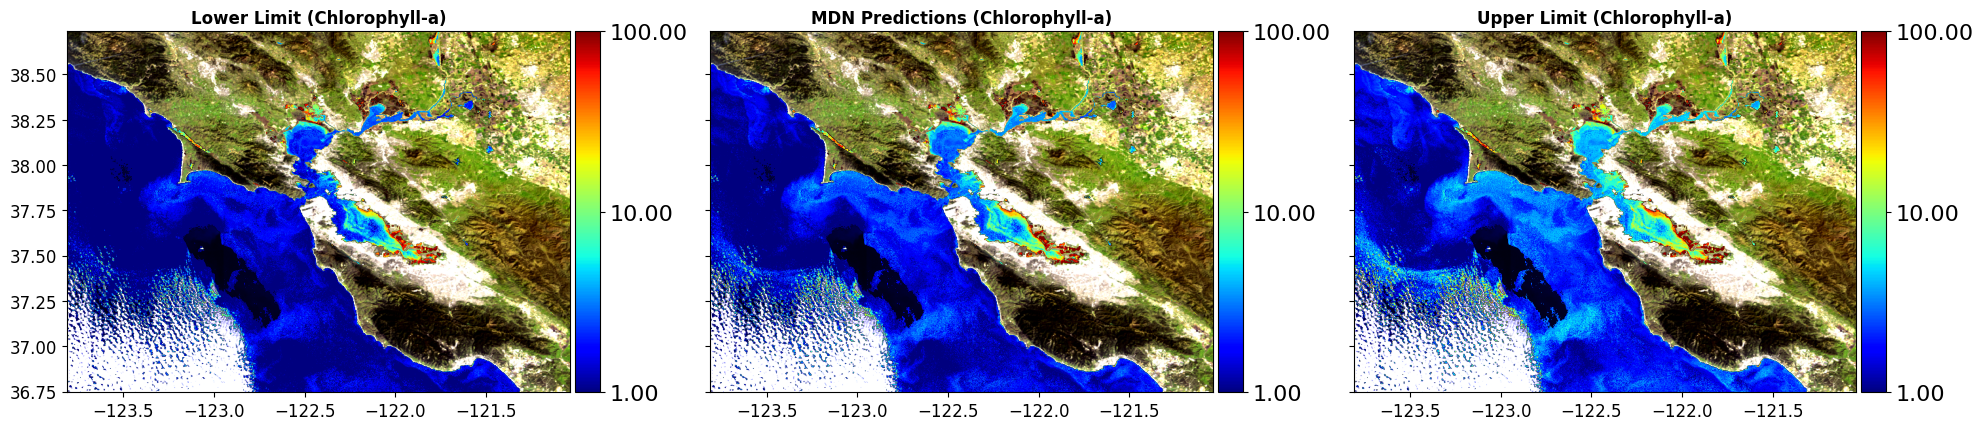

In [23]:
%matplotlib inline
# Get the extent from the data
extent = map_preds.attrs['extent']

str1 = f"Chlorophyll-a"
fig1 = overlay_rgb_mdn_preds_limits(rgb_img= img_rgb, model_preds = map_preds["predictions"].isel(model=0, output=op_slices["chl"]), extent= extent, 
                                    img_uncert_low= map_preds["uncertainty_low"].isel(model=0, output=op_slices["chl"]),
                                    img_uncert_high = map_preds["uncertainty_high"].isel(model=0, output=op_slices["chl"]),
                                    product_name=str1, pred_ticks= [ 0, 1, 2], pred_uncert_ticks = [0, 1, 2], figsize=(20, 7),)

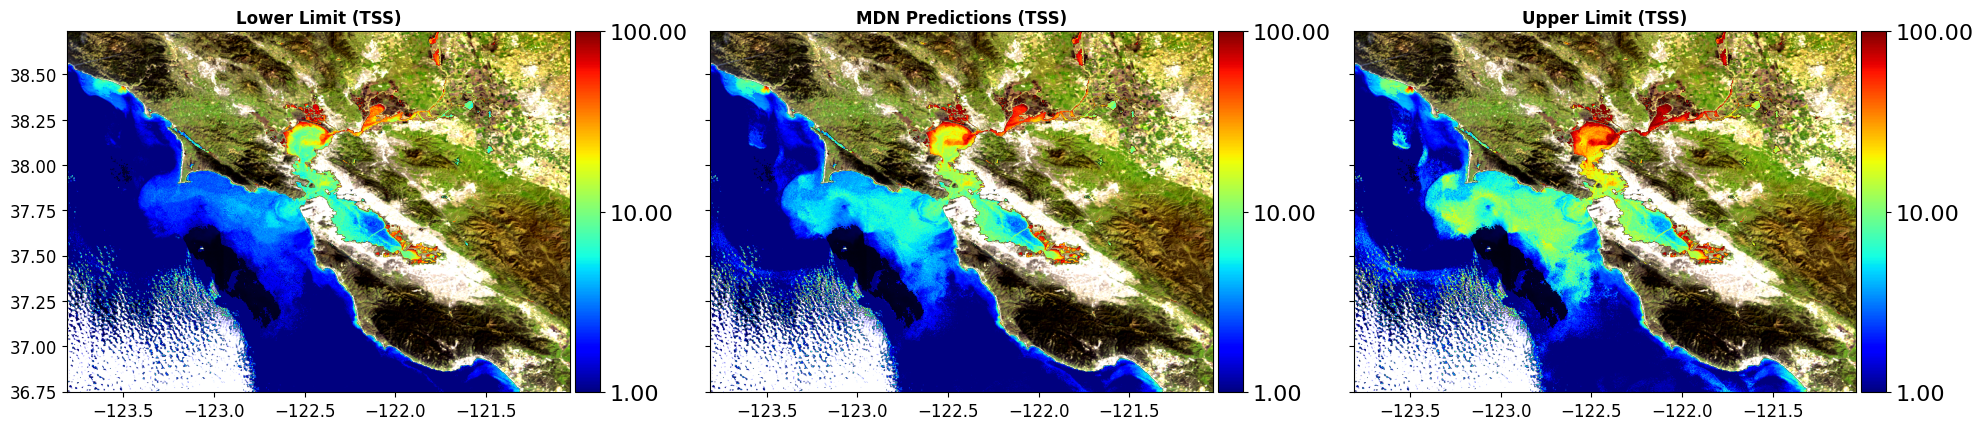

In [24]:
str1 = f"TSS"
fig1 = overlay_rgb_mdn_preds_limits(rgb_img= img_rgb, model_preds = map_preds["predictions"].isel(model=0, output=op_slices["tss"]), extent= extent, 
                                    img_uncert_low= map_preds["uncertainty_low"].isel(model=0, output=op_slices["tss"]),
                                    img_uncert_high = map_preds["uncertainty_high"].isel(model=0, output=op_slices["tss"]),
                                    product_name=str1, pred_ticks= [ 0, 1, 2], pred_uncert_ticks = [0, 1, 2], figsize=(20, 7))

<div style="padding: 20px; border: 2px solid #2c3e50; border-radius: 12px; background-color: #ffffff; color: #1a1a1a; font-family: 'Segoe UI', Helvetica, Arial, sans-serif; line-height: 1.6; width: auto; max-width: 100%; box-sizing: border-box; overflow: hidden;">

<p style="margin-bottom: 15px; word-wrap: break-word;">The figures above map the spatial distributions and modeled uncertainty bounds for both <strong>Chlorophyll-a (Chl-a)</strong> and <strong>Total Suspended Solids (TSS)</strong> derived from the <strong>Mixture Density Network (MDN)</strong> pipeline.</p>

<hr style="border: 0; border-top: 1px solid #e0e0e0; margin: 20px 0;" />

<h3 style="margin-top: 0; margin-bottom: 10px; color: #2c3e50; font-size: 1.15em;">Model Predictions & Uncertainty Quantifications</h3>

<p style="margin-bottom: 12px; word-wrap: break-word;">By outputting a full probability density function per pixel, the MDN provides a complete statistical profile (central expected value along with confidence limits) for each parameter:</p>

<ul style="margin-bottom: 15px; padding-left: 20px; word-wrap: break-word;">
    <li style="margin-bottom: 6px;"><strong>Lower Limit (Left Panels):</strong> Represents the lower prediction bound (e.g., lower percentiles / &mu; &minus; &sigma;).</li>
    <li style="margin-bottom: 6px;"><strong>MDN Predictions (Center Panels):</strong> The primary retrieved concentration values for Chl-a (mg/m³) and TSS (g/m³ or mg/L).</li>
    <li style="margin-bottom: 6px;"><strong>Upper Limit (Right Panels):</strong> Represents the upper prediction bound (e.g., upper percentiles / &mu; + &sigma;).</li>
</ul>

<hr style="border: 0; border-top: 1px solid #e0e0e0; margin: 20px 0;" />

<h3 style="margin-top: 0; margin-bottom: 10px; color: #2c3e50; font-size: 1.15em;">Comparative Spatial Analysis</h3>

<ul style="margin-bottom: 15px; padding-left: 20px; word-wrap: break-word;">
    <li style="margin-bottom: 6px;"><strong>High Sediment Plumes (TSS Dominance):</strong> San Pablo Bay, Suisun Bay, and the Delta exhibit exceptionally high TSS levels (>10 to 100 g/m³), visible as distinct high-turbidity plumes extending out through the Golden Gate into the coastal ocean.</li>
    <li style="margin-bottom: 6px;"><strong>Phytoplankton Dynamics (Chl-a):</strong> While Chl-a follows a similar spatial gradient—peaking in shallow, nutrient-rich estuarine waters—it dissipates much more rapidly towards the coastal interface compared to the suspended sediment plume.</li>
    <li style="margin-bottom: 6px;"><strong>Uncertainty Behavior in Optically Complex Waters:</strong> In highly turbid estuarine zones, the gap between the lower and upper bounds expands considerably for both parameters, reflecting elevated model variance in Case-2 optically complex waters. Conversely, clear open-ocean waters exhibit narrow, highly confident bounds near baseline values (~1.0).</li>
</ul>

<div style="background-color: #fffaf0; color: #b76e00; padding: 15px; border: 1px solid #ffe8cc; border-left: 6px solid #e67e22; margin: 20px 0; box-sizing: border-box;">
    <strong style="font-size: 1.1em;">📍 Geographic Note:</strong> The scene coordinates (~36.75°N to 38.50°N, 121.0°W to 123.5°W) cover the <strong>San Francisco Bay Estuary and Northern California coastal waters</strong>.
</div>

</div>

<div style="padding: 25px; border: 2px solid #2c3e50; border-radius: 12px; background-color: #ffffff; color: #1a1a1a; font-family: 'Segoe UI', Helvetica, Arial, sans-serif; line-height: 1.6; width: auto; max-width: 100%; box-sizing: border-box; overflow: hidden;">

<h2 style="color: #c0392b; border-bottom: 2px solid #c0392b; padding-bottom: 8px; font-weight: 700; margin-top: 0; margin-bottom: 20px; font-size: 1.5em; word-wrap: break-word;">
    Section 5: Saving MDN Predictions
</h2>

<p style="margin-bottom: 15px; word-wrap: break-word;">After generating and inspecting your water quality products, the final step is exporting the output dataset for persistent storage, downstream GIS visualization, or archival. We provide the unified utility function <code>export_dataset()</code> to handle format conversions and array compression seamlessly.</p>

<ul style="padding-left: 20px; margin-bottom: 20px; list-style-type: disc;">
    <li style="margin-bottom: 10px; word-wrap: break-word;">
        <strong>1. Multi-Format Export Options:</strong> Depending on your workflow requirements, <code>export_dataset()</code> supports three primary scientific geospatial formats:
        <ul style="padding-left: 20px; margin-top: 5px; list-style-type: circle;">
            <li style="margin-bottom: 4px;"><strong>NetCDF (<code>.nc</code>):</strong> The standard self-describing format for multi-variable scientific data cubes, ideal for storing predictions alongside lower and upper uncertainty bounds in a single file.</li>
            <li style="margin-bottom: 4px;"><strong>GeoTIFF (<code>.tif</code>):</strong> Best suited for direct ingestion into desktop GIS software (e.g., QGIS, ArcGIS) or web mapping services via <code>rioxarray</code>.</li>
            <li style="margin-bottom: 4px;"><strong>Zarr (<code>.zarr</code>):</strong> A cloud-optimized, chunk-friendly format ideal for high-performance parallel computing environments and object storage (e.g., AWS S3).</li>
        </ul>
    </li>
    <li style="margin-bottom: 10px; word-wrap: break-word;">
        <strong>2. Lossless Compression & Performance Optimization:</strong> Large spatial imagery cubes can quickly consume disk storage. Built-in compression reduces file sizes significantly without losing numerical precision:
        <ul style="padding-left: 20px; margin-top: 5px; list-style-type: circle;">
            <li style="margin-bottom: 4px;"><strong>Compression Levels (1–9):</strong> Controls the tradeoff between write speed and file size reduction.</li>
            <li style="margin-bottom: 4px;"><strong>Levels 1–4:</strong> Ultra-fast write/read speeds with light compression ratios.</li>
            <li style="margin-bottom: 4px;"><strong>Levels 5–6 (Recommended):</strong> The optimal balances between execution time and disk space savings (~50–70% reduction for floating-point raster cubes).</li>
            <li style="margin-bottom: 4px;"><strong>Levels 7–9:</strong> Maximum file size reduction, but requires noticeably higher computational overhead during file writing.</li>
        </ul>
    </li>
</ul>

<div style="background-color: #f8f9fa; border-left: 4px solid #c0392b; padding: 15px; margin: 20px 0; border-radius: 0 4px 4px 0; box-sizing: border-box;">
    <p style="margin: 0; font-weight: 500; word-wrap: break-word;">
        💡 <strong>Pro Tip: Bit-Shuffling for Floating-Point Arrays</strong><br>
        When exporting to NetCDF or Zarr, <code>export_dataset()</code> enables byte/bit-shuffling automatically. For floating-point aquatic reflectance and concentration variables, shuffling reorganizes similar byte patterns before applying <code>zlib</code> or <code>zstd</code> compression, dramatically boosting compression efficiency without degrading data precision.
    </p>
</div>

<hr style="border: 0; border-top: 1px solid #eeeeee; margin: 20px 0;">

<div style="font-size: 0.9em; color: #666666; font-style: italic; text-align: right;">
    Aquaverse Short Course • Module 3.5
</div>

</div>

In [25]:
outfile_name= f"./data/mdn_ouputs/MDN_preds_{location}_{date}.nc"

export_dataset(map_preds,outfile_name,
    file_format= "netcdf",
    complevel= 5,
)

Successfully saved NetCDF (complevel=5): data/mdn_ouputs/MDN_preds_San Francisco Bay_03-16-2019.nc


<div style="padding: 25px; border: 2px solid #2c3e50; border-radius: 12px; background-color: #ffffff; color: #1a1a1a; font-family: 'Segoe UI', Helvetica, Arial, sans-serif; line-height: 1.6; width: auto; max-width: 100%; box-sizing: border-box; overflow: hidden;">

<h2 style="color: #c0392b; border-bottom: 2px solid #c0392b; padding-bottom: 8px; font-weight: 700; margin-top: 0; margin-bottom: 20px; font-size: 1.5em; word-wrap: break-word;">
    Exercise 3.1: Hyperspectral Mapping with NASA PACE
</h2>

<p style="margin-bottom: 15px; word-wrap: break-word;">
    Now it's your turn to put the pipeline into practice! In this exercise, you will step away from multispectral sensors and work with <b>NASA's PACE OCI</b> (Ocean Color Instrument) platform. You will download a hyperspectral scene over <b>Lake Erie</b> acquired on <b>May 31, 2024</b>, inspect its atmospheric and masking metadata, and run the MDN spatial mapping workflow independently.
</p>

<hr style="border: 0; border-top: 1px solid #e0e0e0; margin: 20px 0;" />

<h3 style="margin-top: 0; margin-bottom: 10px; color: #2c3e50; font-size: 1.2em;">Task Checklist</h3>

<ol style="padding-left: 20px; margin-bottom: 20px; line-height: 1.8;">
    <li style="margin-bottom: 10px; word-wrap: break-word;">
        <strong>Download & Load Imagery:</strong> Update the parameters to download the <code>PACE</code> sensor imagery for <code>"Lake Erie"</code> on <code>"05-31-2024"</code>. Open the downloaded file using <code>xr.open_dataset()</code>.
    </li>
    <li style="margin-bottom: 10px; word-wrap: break-word;">
        <strong>Metadata & Parameter Inspection:</strong> Extract key metadata attributes (processing date, bounding box, masking settings) and summarize the available spectral parameter keys.
    </li>
    <li style="margin-bottom: 10px; word-wrap: break-word;">
        <strong>Masking Verification:</strong> Plot the TOA RGB image and compare it against a Level-2 surface reflectance (<span style="font-family: 'Times New Roman', serif; font-weight: bold; font-style: italic;">R<sub style="font-style: normal; font-size: 0.75em; vertical-align: sub;">rs</sub></span>) band to check water and cloud mask boundaries over Lake Erie.
    </li>
    <li style="margin-bottom: 10px; word-wrap: break-word;">
        <strong>MDN Spatial Retrieval:</strong> Execute <code>map_cube_mdn()</code> targeting Chlorophyll-a (<code>'chl'</code>) and Total Suspended Solids (<code>'tss'</code>) using the <code>PACE</code> sensor model.
    </li>
    <li style="margin-bottom: 10px; word-wrap: break-word;">
        <strong>Export Results:</strong> Save your multi-variable output cube to a compressed NetCDF file using <code>export_dataset()</code>.
    </li>
</ol>

<div style="background-color: #f8f9fa; border-left: 4px solid #c0392b; padding: 15px; margin: 20px 0; border-radius: 0 4px 4px 0; box-sizing: border-box;">
    <p style="margin: 0; font-weight: 500; word-wrap: break-word;">
        💡 <strong>Hyperspectral Tip:</strong> PACE OCI provides continuous 5 nm spectral resolution across UV-VIS-NIR wavelengths. Notice how the extracted parameter keys differ in density compared to multispectral sensors like OLCI or Sentinel-2!
    </p>
</div>

<div style="background-color: #fdf2f2; color: #9b1c1c; padding: 15px; border: 1px solid #f8b4b4; border-left: 6px solid #e11d48; margin: 20px 0; box-sizing: border-box; border-radius: 4px;">
    <strong style="font-size: 1.1em;">⚠️ Team Internal Note: Things to implement in this section</strong>
    <ol style="margin-top: 5px; margin-bottom: 0; padding-left: 20px; line-height: 1.7;">
        <li><b>Provide Starter Code Skeleton:</b> Ensure the starter block below is uncommented in the final student notebook release.</li>
        <li><b>Sample Solution Dropdown:</b> Add a collapsible <code>&lt;details&gt;</code> HTML block containing the full working execution code for PACE Lake Erie.</li>
    </ol>
</div>

<hr style="border: 0; border-top: 1px solid #eeeeee; margin: 20px 0;">

<div style="font-size: 0.9em; color: #666666; font-style: italic; text-align: right;">
    Aquaverse Short Course • Exercise 3.1
</div>

</div>

In [26]:
# ==============================================================================
# EXERCISE: Download & Inspect PACE Scene over Lake Erie (05/31/2024)
# ==============================================================================

# TODO: Fill in the parameters for the PACE scene
sensor = "PACE-delivery"
products = "chl,tss,aph"
date = "05-31-2024"
location = "Lake Erie"

# Download the example imagery tile
tile_path = download_example_imagery(
    sensor=sensor.split("-")[0], date=date, location=location
)

# Open the NetCDF dataset lazily using xarray
ds = xr.open_dataset(tile_path)

# ------------------------------------------------------------------------------
# 1. Gather Metadata Dictionary
# ------------------------------------------------------------------------------
useful_metadata = {
    "Core Information": {
        "Processor/Software": ds.attrs.get("generated_by"),
        "Processing Date": ds.attrs.get("generated_on"),
        "Sensor Baseline": ds.attrs.get("sensor"),
        "Acquisition Time": ds.attrs.get("isodate"),
        "File Type": ds.attrs.get("acolite_file_type"),
    },
    "Spatial Dimensions & Bounds": {
        "Image Dimensions (Px)": ds.attrs.get("data_dimensions"),
        "Spatial Bounding Box": ds.attrs.get("limit"),
    },
    "Atmospheric & Environmental Context": {
        "Solar Zenith Angle (SZA)": round(ds.attrs.get("sza", 0), 2),
        "View Zenith Angle (VZA)": round(ds.attrs.get("vza", 0), 2),
        "Ozone Column (uoz)": ds.attrs.get("uoz"),
        "Water Vapor (uwv)": ds.attrs.get("uwv"),
        "Ancillary Data Source": ds.attrs.get("ancillary_type"),
    },
    "Masking Settings (Crucial for MDN)": {
        "Land/Water Masking Wave": f"{ds.attrs.get('l2w_mask_wave')} nm",
        "Water Mask Threshold": ds.attrs.get("l2w_mask_threshold"),
        "High TOA Cloud Masking": str(ds.attrs.get("l2w_mask_high_toa")),
    },
}

# ------------------------------------------------------------------------------
# 2. Extract Unique Parameter Keys
# ------------------------------------------------------------------------------
coordinate_vars = {"lat", "lon", "transverse_mercator", "x", "y"}
unique_parameter_keys = set()

for var in ds.data_vars:
    if var in coordinate_vars:
        continue
    # Strip wavelength suffixes (e.g., rhow_443 -> rhow)
    base_key = re.sub(r"_\d+$", "", var)
    unique_parameter_keys.add(base_key)


# Convert back to a sorted list
sorted_keys = sorted(list(unique_parameter_keys))

# 3. Print the full summary
print("=" * 60)
print("             SATELLITE NETCDF MULTI-PREVIEW             ")
print("=" * 60)

# Print attributes
for section, items in useful_metadata.items():
    print(f"\n📁 {section.upper()}")
    print("-" * len(section))
    for key, value in items.items():
        if isinstance(value, list) or str(type(value)).endswith("ndarray'>"):
            value = [round(x, 4) for x in value] if isinstance(value[0], (int, float)) else value
        print(f"  🔹 {key:<26} : {value}")

# Print unique parameter fields
print("\n📊 AVAILABLE PARAMETER KEYS (Wavelength Repeats Dropped)")
print("-------------------------------------------------------")
print(f"  👉 {', '.join(sorted_keys)}")
print("\n" + "=" * 60)    

             SATELLITE NETCDF MULTI-PREVIEW             

📁 CORE INFORMATION
----------------
  🔹 Processor/Software         : None
  🔹 Processing Date            : None
  🔹 Sensor Baseline            : None
  🔹 Acquisition Time           : None
  🔹 File Type                  : None

📁 SPATIAL DIMENSIONS & BOUNDS
---------------------------
  🔹 Image Dimensions (Px)      : None
  🔹 Spatial Bounding Box       : None

📁 ATMOSPHERIC & ENVIRONMENTAL CONTEXT
-----------------------------------
  🔹 Solar Zenith Angle (SZA)   : 0
  🔹 View Zenith Angle (VZA)    : 0
  🔹 Ozone Column (uoz)         : None
  🔹 Water Vapor (uwv)          : None
  🔹 Ancillary Data Source      : None

📁 MASKING SETTINGS (CRUCIAL FOR MDN)
----------------------------------
  🔹 Land/Water Masking Wave    : None nm
  🔹 Water Mask Threshold       : None
  🔹 High TOA Cloud Masking     : None

📊 AVAILABLE PARAMETER KEYS (Wavelength Repeats Dropped)
-------------------------------------------------------
  👉 



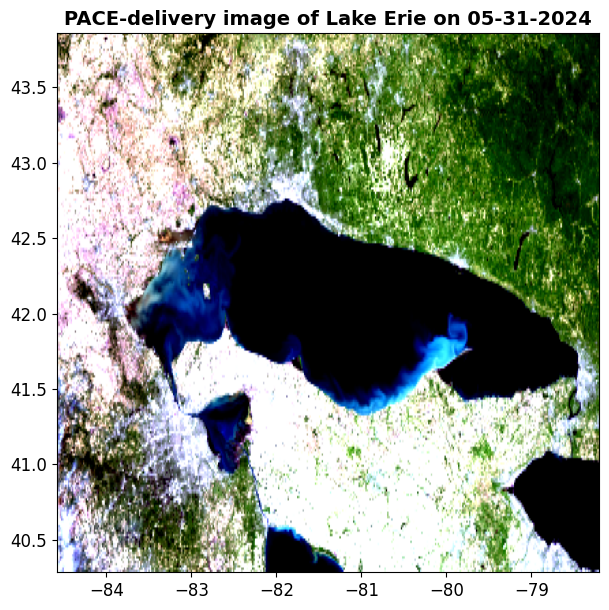

In [27]:
#TODO: now display the RGB of the downloaded tile -- this will use the rhos data from the NetCDF file to create a true color image
img_rgb = display_sat_rgb(tile_path, sensor, figsize=(7,7), title=f"{sensor} image of {location} on {date}", ipython_mode=True)

NetCDF file source detected. Delegating to extract_netcdf_satellite_rrs for sensor PACE-delivery: sat_cube.nc
Hierarchical group schema detected. Accessing nested groups.
Extracted/Assigned Dataset CRS: EPSG:4326
Auto-detected variable type: RRS
Selected variables: ['Rrs_410', 'Rrs_415', 'Rrs_420', 'Rrs_425', 'Rrs_430', 'Rrs_435', 'Rrs_440', 'Rrs_445', 'Rrs_450', 'Rrs_455', 'Rrs_460', 'Rrs_465', 'Rrs_470', 'Rrs_475', 'Rrs_480', 'Rrs_485', 'Rrs_490', 'Rrs_495', 'Rrs_500', 'Rrs_505', 'Rrs_510', 'Rrs_515', 'Rrs_520', 'Rrs_525', 'Rrs_530', 'Rrs_535', 'Rrs_540', 'Rrs_545', 'Rrs_550', 'Rrs_555', 'Rrs_560', 'Rrs_565', 'Rrs_570', 'Rrs_575', 'Rrs_580', 'Rrs_586', 'Rrs_591', 'Rrs_615', 'Rrs_620', 'Rrs_625', 'Rrs_630', 'Rrs_635', 'Rrs_640', 'Rrs_645', 'Rrs_650', 'Rrs_655', 'Rrs_660', 'Rrs_665', 'Rrs_670', 'Rrs_675', 'Rrs_679', 'Rrs_684', 'Rrs_689', 'Rrs_694', 'Rrs_699', 'Rrs_704', 'Rrs_709', 'Rrs_714', 'Rrs_719']
Output spectral shape: (59, 241, 398) (band, y, x)
Latitude/Longitude shape: (241, 3

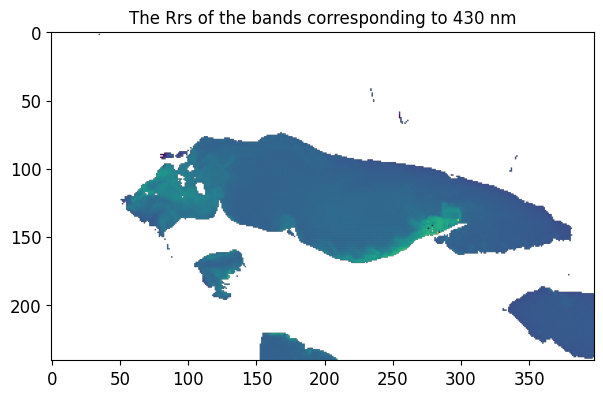

In [28]:
# TODO Let us now extract the Rrs data
bands = get_sensor_bands(sensor)
da= extract_satellite_data(tile_path, sensor=sensor, bands=bands, wavelength_unit="nm", verbose=True, flag_toa=False, chunk_size=100)

# Display the results - for the first band
fig1, ax1 = plt.subplots(figsize=(7,7))
fig1.patch.set_visible(True)

bnd= 4
img1 = ax1.imshow(da.isel(band=bnd), cmap="viridis")
ax1.set_title(f'The Rrs of the bands corresponding to {bands[bnd]} nm');

In [29]:
# TODO Generate MDN predictions for this dataset
map_preds, op_slices = map_cube_mdn(da, sensor=sensor, products=products, return_uncert=True, uncert_mode="limits", scaler_mode="invert", progress_vis=True)
map_preds

Computing MDN predictions across chunks...
[                                        ] | 0% Completed | 72.29 us

[###########################             ] | 68% Completed | 107.60 ms

[###########################             ] | 68% Completed | 212.88 ms

[###########################             ] | 68% Completed | 318.13 ms

[###########################             ] | 68% Completed | 423.45 ms

...

[######################################  ] | 97% Completed | 38.99 s

[######################################  ] | 97% Completed | 39.09 s

[######################################  ] | 97% Completed | 39.19 s

[########################################] | 100% Completed | 39.44 s


<xarray.Dataset> Size: 64MB
Dimensions:           (model: 1, output: 55, y: 241, x: 398)
Coordinates:
  * model             (model) int64 8B 0
  * output            (output) int64 440B 0 1 2 3 4 5 6 ... 48 49 50 51 52 53 54
  * y                 (y) int64 2kB 0 1 2 3 4 5 6 ... 235 236 237 238 239 240
  * x                 (x) int64 3kB 0 1 2 3 4 5 6 ... 392 393 394 395 396 397
    latitude          (y, x) float32 384kB 40.28 40.29 40.29 ... 43.86 43.86
    longitude         (y, x) float32 384kB -83.7 -83.69 -83.67 ... -78.88 -78.87
    spatial_ref       int64 8B 0
Data variables:
    predictions       (model, y, x, output) float32 21MB -999.0 ... -999.0
    uncertainty_low   (model, y, x, output) float32 21MB -999.0 ... -999.0
    uncertainty_high  (model, y, x, output) float32 21MB -999.0 ... -999.0
Attributes:
    title:                MDN Satellite Product Predictions
    sensor:               PACE-delivery
    target_products:      chl,tss,aph
    operation_mode:       select
    land_mask_applied:    False
    land_mask_threshold:  0.0
    scaler_mode:          invert
    no_data_value:        -999.0
    extent:               [-84.58548736572266, -78.20340728759766, 40.2849540...
    history:              Created on 2026-09-07 13:24:53 using map_cube_mdn
    aph_wavelengths:      [410, 415, 420, 425, 430, 435, 440, 445, 450, 455, ...

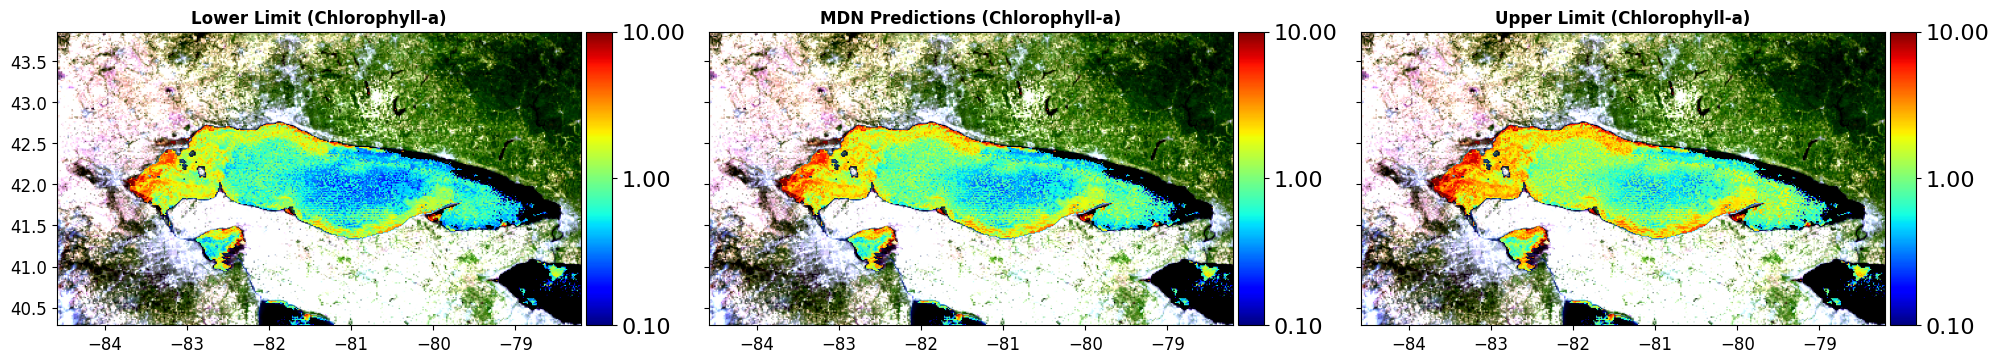

In [30]:
# Get the extent from the data
extent = map_preds.attrs['extent']

str1 = f"Chlorophyll-a"
fig1 = overlay_rgb_mdn_preds_limits(rgb_img= img_rgb, model_preds = map_preds["predictions"].isel(model=0, output=op_slices["chl"]), extent= extent, 
                                    img_uncert_low= map_preds["uncertainty_low"].isel(model=0, output=op_slices["chl"]),
                                    img_uncert_high = map_preds["uncertainty_high"].isel(model=0, output=op_slices["chl"]),
                                    product_name=str1, pred_ticks= [ -1,0,1], pred_uncert_ticks = [-1, 0, 1], figsize=(20, 7),)

In [31]:
#TODO save your outputs

outfile_name= f"./data/mdn_ouputs/MDN_preds_{location}_{date}.nc"

export_dataset(map_preds,outfile_name,
    file_format= "netcdf",
    complevel= 5,
)

Successfully saved NetCDF (complevel=5): data/mdn_ouputs/MDN_preds_Lake Erie_05-31-2024.nc


<div style="padding: 25px; border: 2px solid #2c3e50; border-radius: 12px; background-color: #ffffff; color: #1a1a1a; font-family: 'Segoe UI', Helvetica, Arial, sans-serif; line-height: 1.6; box-sizing: border-box; max-width: 100%; word-wrap: break-word; overflow-wrap: break-word;">

<h2 style="color: #004080; border-bottom: 3px solid #004080; padding-bottom: 10px; font-weight: 800; margin-top: 0;">
    Conclusion: End-to-End MDN Spatial Mapping
</h2>

<p style="font-size: 1.15em; color: #222222;">
    In this final module, we have walked through the complete pipeline for generating, visualizing, and exporting spatial water quality retrievals from satellite imagery using pre-trained <b>Mixture Density Networks (MDNs)</b>. By bridging raw sensor inputs with parallelized Dask processing, you now have the full toolkit to convert Level-2 surface reflectances (<span style="font-family: 'Times New Roman', serif; font-weight: bold; font-style: italic; color: #000000;">R<sub style="font-style: normal; font-size: 0.75em; vertical-align: sub;">rs</sub></span>) into actionable, uncertainty-quantified geospatial products.
</p>

<h3 style="color: #004080; margin-top: 25px;"><b>Key Takeaways</b></h3>
<ul style="line-height: 1.9; color: #1a1a1a; list-style-type: none; padding-left: 0;">
    <li><span style="color: #27ae60;">✔</span> <b>Quality Verification:</b> You visually confirmed masking integrity by comparing raw Top of Atmosphere (TOA) RGB imagery against Level-2 single-band <span style="font-family: 'Times New Roman', serif; font-weight: bold; font-style: italic;">R<sub style="font-style: normal; font-size: 0.75em; vertical-align: sub;">rs</sub></span> data.</li>
    <li><span style="color: #27ae60;">✔</span> <b>Scalable Inference:</b> Using <code>map_cube_mdn()</code>, you executed chunk-based, parallelized model execution across an entire satellite scene to derive central estimates alongside upper (&mu; + &sigma;) and lower (&mu; &minus; &sigma;) confidence bounds.</li>
    <li><span style="color: #27ae60;">✔</span> <b>Spatial Visualization:</b> You inspected spatial gradients and prediction spreads across complex water bodies using three-panel product overlays with logarithmic color scaling.</li>
    <li><span style="color: #27ae60;">✔</span> <b>Optimized Archival:</b> Using <code>export_dataset()</code>, you learned how to compress and save spatial outputs into NetCDF, GeoTIFF, or Zarr formats with balanced compression settings (complevel 5–6) for downstream GIS or cloud workflows.</li>
</ul>

<div style="background-color: #e8f4fd; color: #2c3e50; padding: 15px; border: 1px solid #d1e9f9; border-left: 6px solid #004080; margin: 25px 0; box-sizing: border-box; max-width: 100%; word-wrap: break-word; overflow-wrap: break-word;">
    <strong style="font-size: 1.1em;">Ready for Your Own Data!</strong><br>
    Congratulations on completing the course! We encourage you to test these MDN mapping workflows on your own satellite scenes and regional aquatic target areas. If you run into questions, encounter unexpected edge cases, or have feedback on the package, please reach out to our team or submit an issue on our GitHub repository.
</div>

<hr style="border: 0; border-top: 2px solid #eee;">

<div style="display: flex; justify-content: space-between; align-items: center; margin-top: 20px;">
    <div>
        <strong style="color: #004080; font-size: 1.1em;">Freshwater Sensing Group</strong><br>
        <span style="color: #666; font-size: 0.95em;">SSAI / NASA Goddard Space Flight Center</span>
    </div>
    <div style="text-align: right;">
        <span style="font-size: 0.9em; color: #999; font-style: italic;">End of Course</span><br>
        <a href="https://ladsweb.modaps.eosdis.nasa.gov/stream/" target="_blank" style="color: #0056b3; font-weight: bold; text-decoration: none; font-size: 0.9em;">Visit STREAM Website →</a>
    </div>
</div>

</div>